# Data Analysis, Cleanup and Visualization

This data was collected periodically from sensors placed stategically across the farm and stored in the following files:
1. weather_daily.csv - Contains daily synthetic weather data for 30 days.
2. soil_sensor_data.csv - Contains daily noon sensor readings for three farm zones.
3. crop_zone_parameters.csv - Contains zone-level crop and soil-water parameters.


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

### Load the data

In [2]:
weather_raw = pd.read_csv("../data/raw/weather_daily.csv")
weather_raw.head()

,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
0,2026-03-01,3.2,23.8,69.7,2.28,0.78
1,2026-03-02,2.2,25.9,62.0,1.62,0.71
2,2026-03-03,3.0,26.8,64.4,2.11,0.75
3,2026-03-04,1.6,27.0,64.6,2.09,0.58
4,2026-03-05,23.7,26.6,61.0,1.36,0.62


In [3]:
weather_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            30 non-null     str    
 1   rainfall_mm     29 non-null     float64
 2   temperature_c   30 non-null     float64
 3   humidity_pct    29 non-null     float64
 4   wind_speed_mps  30 non-null     float64
 5   solar_index     30 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.5 KB


1. **Daily weather data**
    - Stored in `weather_raw`
    - 30 rows representing 30 consecutive days
    - Columns:  
      - `date`: day of observation
      - `rainfall_mm`: daily rainfall in millimeters
      - `temperature_c`: daily air temperature in Celsius
      - `humidity_pct`: relative humidity percentage
      - `wind_speed_mps`: wind speed in meters per second
      - `solar_index`: solar radiation index
    - Notes:
      - There are missing values in `rainfall_mm` and `humidity_pct`
      - Most values are numeric floats except for the date column

In [4]:
crop_raw = pd.read_csv("../data/raw/crop_zone_parameters.csv")
crop_raw.head()

,zone_id,crop_type,area_m2,min_moisture_pct,target_moisture_pct,field_capacity_pct,drainage_coefficient
0,Zone_A,tomato,120,22,33,41,0.18
1,Zone_B,kale,90,24,35,43,0.15
2,Zone_C,maize,180,20,31,40,0.22


In [5]:
crop_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   zone_id               3 non-null      str    
 1   crop_type             3 non-null      str    
 2   area_m2               3 non-null      int64  
 3   min_moisture_pct      3 non-null      int64  
 4   target_moisture_pct   3 non-null      int64  
 5   field_capacity_pct    3 non-null      int64  
 6   drainage_coefficient  3 non-null      float64
dtypes: float64(1), int64(4), str(2)
memory usage: 300.0 bytes


2. **Crop zone parameters**
    - Stored in `crop_raw`
    - 3 rows representing three farm zones: `Zone_A`, `Zone_B`, `Zone_C`
    - Columns:
      - `zone_id`: unique zone identifier
      - `crop_type`: crop grown in each zone
      - `area_m2`: zone area in square meters
      - `min_moisture_pct`: minimum soil moisture threshold
      - `target_moisture_pct`: target soil moisture level
      - `field_capacity_pct`: soil field capacity percentage
      - `drainage_coefficient`: zone-specific drainage coefficient

In [6]:
soil_raw = pd.read_csv("../data/raw/soil_sensor_data.csv")
soil_raw.head()

,timestamp,zone_id,soil_moisture_pct,tank_level_liters,pump_flow_lpm,pump_power_watts,sensor_status
0,2026-03-01 12:00,Zone_A,33.2,4829,18.8,437,OK
1,2026-03-01 12:00,Zone_B,34.7,4728,22.1,461,OK
2,2026-03-01 12:00,Zone_C,28.2,4515,25.7,490,OK
3,2026-03-02 12:00,Zone_A,36.1,4757,16.6,411,OK
4,2026-03-02 12:00,Zone_B,32.0,4645,20.4,445,OK


In [7]:
soil_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          90 non-null     str    
 1   zone_id            90 non-null     str    
 2   soil_moisture_pct  89 non-null     float64
 3   tank_level_liters  90 non-null     int64  
 4   pump_flow_lpm      90 non-null     float64
 5   pump_power_watts   90 non-null     int64  
 6   sensor_status      90 non-null     str    
dtypes: float64(2), int64(2), str(3)
memory usage: 5.1 KB


3. **Soil sensor data**
    - Stored in `soil_raw`
    - 90 rows representing daily noon sensor readings for three farm zones: `Zone_A`, `Zone_B`, `Zone_C`
    - Columns:
      - `timestamp`: timestamp of sensor reading
      - `zone_id`: zone identifier
      - `soil_moisture_pct`: soil moisture percentage
      - `tank_level_liters`: water tank level in liters
      - `pump_flow_lpm`: pump flow rate in liters per minute
      - `pump_power_watts`: pump power consumption in watts
      - `sensor_status`: sensor operational status
    
    -Notes:
    - `soil_moisture_pct` has a null value

In [8]:
# we will work on copies of the data so that raw dfs remain

weather = weather_raw.copy()
soil = soil_raw.copy()
crop = crop_raw.copy()

## Detecting Outliers in the Data Using Interquartile Range (IQR)

Outliers are data points that differ significantly from the other observations in the dataset.

Outlier detection is critical to avoid building models that are skewed/influenced to false data points.

The **Interquartile Range (IQR)** method is a mathematical technique used to identify anomalies without assuming a normal distribution of the data. It is important not to assume a normal distribution in the data because real-world environmental data rarely follows it. Data like wind and soil are heavily assymetrical because of frequent low wind/rain and busts of heavy rainfall/strong winds. 

Unlike othermethods, IQR is resistant to being skewed by the outliers themselves because it relies on percentiles rather than the mean and standard deviation.

---

#### 1. Core Concepts

The dataset is divided into quarters (quartiles) based on sorted values:

* **$Q_1$ (25th Percentile / First Quartile):** The median of the lower half of the dataset.
* **$Q_2$ (50th Percentile / Median):** The middle value of the dataset.
* **$Q_3$ (75th Percentile / Third Quartile):** The median of the upper half of the dataset.

The **IQR** represents the middle $50\%$ of the data, which is the bulk of the data:

$$\text{IQR} = Q_3 - Q_1$$

---

#### 2. Mathematical Bounds

To detect outliers, we establish an acceptable "spread" beyond the middle $50\%$. Any data point falling outside these lower and upper boundaries is flagged as an anomaly.

* **Lower Bound:** $$\text{Lower Bound} = Q_1 - (1.5 \times \text{IQR})$$
* **Upper Bound:** $$\text{Upper Bound} = Q_3 + (1.5 \times \text{IQR})$$

> **Note on the $1.5$ Multiplier:** This is the standard industry threshold established by statistician John Tukey. For a normal distribution, it encompasses roughly $99.3\%$ of the data. To catch only *extreme* outliers, this multiplier can be increased.

---

#### 3. Algorithm

##### Step 1: Sort the Dataset
Arrange your data points in ascending order. This is done automatically by pandas when we call **.quantile(0.25)** and **.quantile(0.75)**

##### Step 2: Calculate $Q_1$ and $Q_3$
Find the values at the 25th and 75th percentiles. Done by calling **.quantile(0.25)** and **.quantile(0.75)**

##### Step 3: Compute the IQR
Subtract $Q_1$ from $Q_3$.

##### Step 4: Calculate the Thresholds
Compute your upper and lower fences using the formulas above.

##### Step 5: Filter Outliers
Identify any data point where:
$$\text{Value} < \text{Lower Bound} \quad \text{or} \quad \text{Value} > \text{Upper Bound}$$

---

#### 4. Visualizing

The anomalies identified by the IQR method are plotted directly on charts for each variable. 
- Points marked in red are IQR outliers — values that fall outside the Q1 − 1.5×IQR or Q3 + 1.5×IQR bounds. 
- Orange markers indicate missing values (NaN). 
- The dashed red horizontal lines on each chart show exactly where the upper and lower IQR fences sit, making it easy to see how far an outlier sits outside the expected range.



=== Weather anomalies ===

  [rainfall_mm]  IQR bounds = (-10.40, 19.20)
    Missing values:
      date  rainfall_mm
2026-03-08          NaN
    IQR outliers:
      date  rainfall_mm
2026-03-05         23.7
2026-03-19         26.3
2026-03-26         85.0

  [temperature_c]  IQR bounds = (18.15, 31.55)
    IQR outliers:
      date  temperature_c
2026-03-14           45.8

  [humidity_pct]  IQR bounds = (56.30, 75.50)
    Missing values:
      date  humidity_pct
2026-03-21           NaN
    IQR outliers:
      date  humidity_pct
2026-03-16          56.3


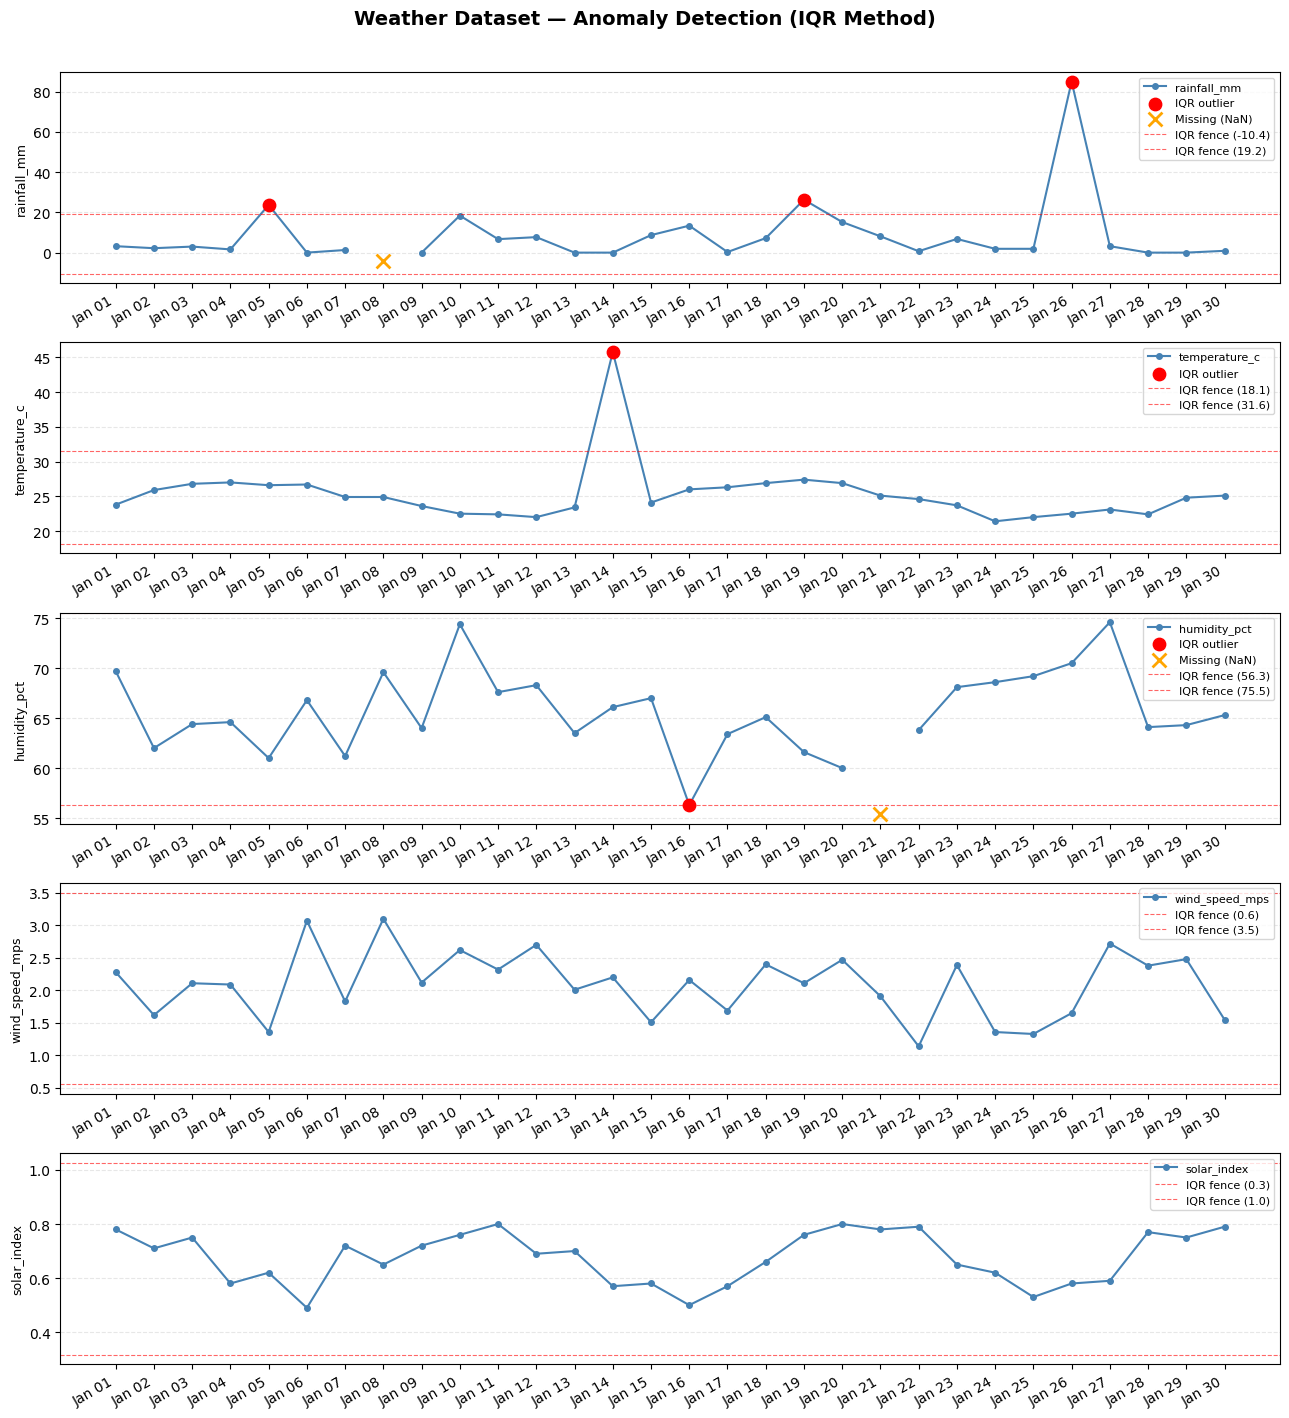


=== Soil sensor anomalies ===

  Zone_B [soil_moisture_pct]  IQR bounds = (18.70, 39.50)
    Missing:
       timestamp  soil_moisture_pct
2026-03-06 12:00                NaN
    Outliers:
       timestamp  soil_moisture_pct
2026-03-25 12:00                8.5

  Zone_B [pump_flow_lpm]  IQR bounds = (17.80, 25.60)
    Outliers:
       timestamp  pump_flow_lpm
2026-03-21 12:00            0.0

  Zone_B [pump_power_watts]  IQR bounds = (425.88, 496.88)
    Outliers:
       timestamp  pump_power_watts
2026-03-26 12:00               500

  Zone_C [tank_level_liters]  IQR bounds = (2813.75, 5239.75)
    Outliers:
       timestamp  tank_level_liters
2026-03-14 12:00               9900

  Zone_C [pump_flow_lpm]  IQR bounds = (23.23, 28.22)
    Outliers:
       timestamp  pump_flow_lpm
2026-03-04 12:00           28.8

  Zone_C [pump_power_watts]  IQR bounds = (468.50, 518.50)
    Outliers:
       timestamp  pump_power_watts
2026-03-11 12:00               463
2026-03-18 12:00               523
2

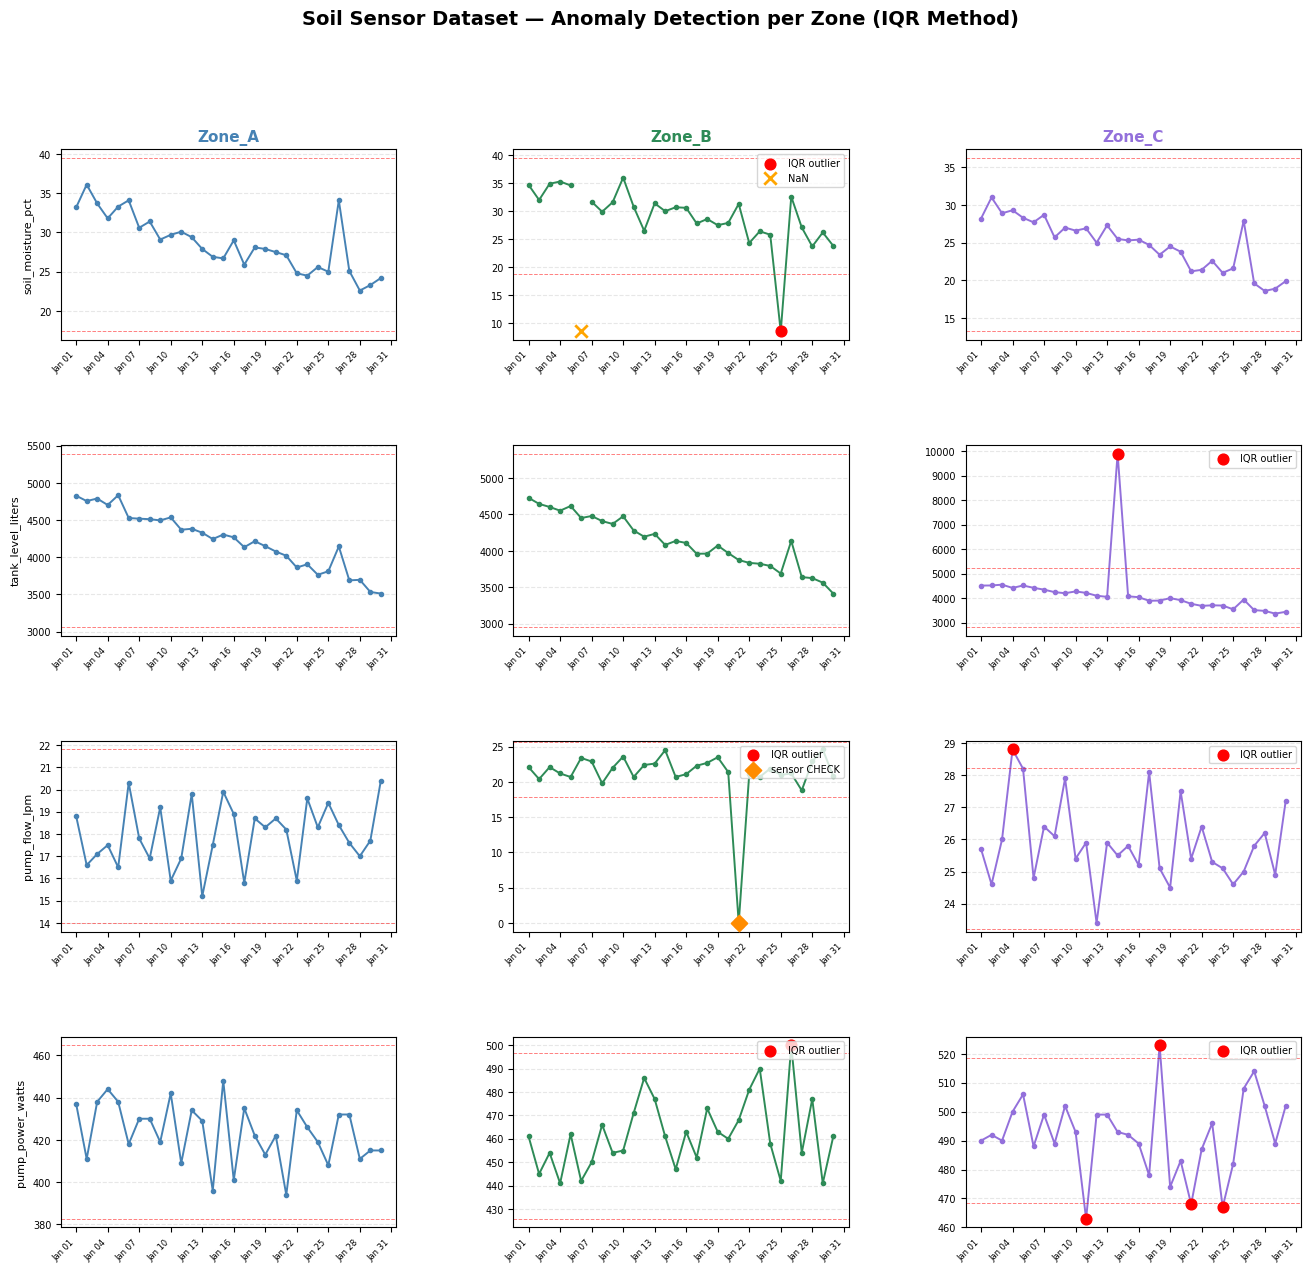


=== Crop zone parameters anomalies ===
  No missing values or IQR outliers detected.
  This is a small reference table (3 rows); IQR bounds are very tight
  by construction — any variation would flag as an outlier. Visual
  inspection and domain knowledge confirm all values are plausible.


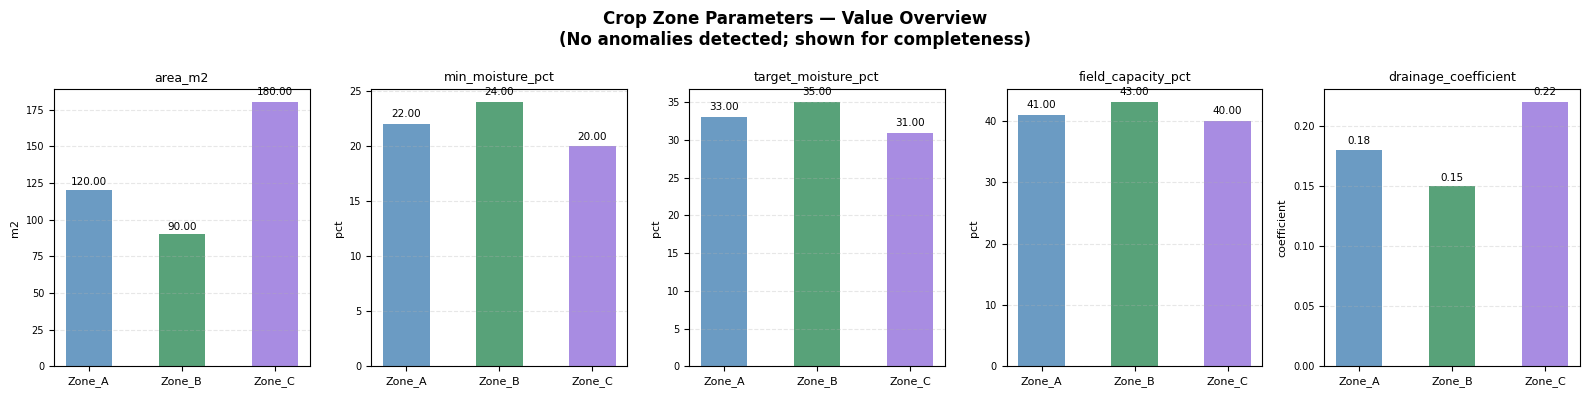

In [9]:
def get_outliers(df, col, id_col):
    """
    Return a boolean mask of IQR outliers for `col` in `df`.
    Uses Tukey's fence: flag values outside Q1-1.5*IQR .. Q3+1.5*IQR.
    NaNs are excluded from flagging (handled separately as missing values).
    """
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr    = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return df[col].notna() & ((df[col] < lo) | (df[col] > hi)), lo, hi


# =============================================================================
# WEATHER ANOMALIES
# =============================================================================

print("=== Weather anomalies ===")

weather_numeric = ['rainfall_mm', 'temperature_c', 'humidity_pct',
                   'wind_speed_mps', 'solar_index']

for col in weather_numeric:
    mask, lo, hi = get_outliers(weather, col, 'date')
    nan_mask = weather[col].isna()
    if mask.any() or nan_mask.any():
        print(f"\n  [{col}]  IQR bounds = ({lo:.2f}, {hi:.2f})")
        if nan_mask.any():
            print(f"    Missing values:\n{weather.loc[nan_mask, ['date', col]].to_string(index=False)}")
        if mask.any():
            print(f"    IQR outliers:\n{weather.loc[mask, ['date', col]].to_string(index=False)}")


# ── Weather plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(weather_numeric), 1, figsize=(13, 14))
fig.suptitle('Weather Dataset — Anomaly Detection (IQR Method)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, col in zip(axes, weather_numeric):
    mask, lo, hi = get_outliers(weather, col, 'date')
    nan_mask = weather[col].isna()

    # Normal points
    ax.plot(weather['date'], weather[col],
            color='steelblue', linewidth=1.5, marker='o', markersize=4,
            label=col)

    # IQR outliers in red
    if mask.any():
        ax.scatter(weather.loc[mask, 'date'], weather.loc[mask, col],
                   color='red', zorder=5, s=80, label='IQR outlier')

    # NaN positions as orange markers on the x-axis
    if nan_mask.any():
        ax.scatter(weather.loc[nan_mask, 'date'],
                   [ax.get_ylim()[0]] * nan_mask.sum(),
                   color='orange', marker='x', s=100, zorder=5,
                   linewidths=2, label='Missing (NaN)')

    # IQR fence lines
    ax.axhline(lo, color='red', linestyle='--', linewidth=0.8, alpha=0.6,
               label=f'IQR fence ({lo:.1f})')
    ax.axhline(hi, color='red', linestyle='--', linewidth=0.8, alpha=0.6,
               label=f'IQR fence ({hi:.1f})')

    ax.set_ylabel(col, fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


# =============================================================================
# SOIL SENSOR ANOMALIES
# =============================================================================

print("\n=== Soil sensor anomalies ===")

soil_numeric = ['soil_moisture_pct', 'tank_level_liters',
                'pump_flow_lpm', 'pump_power_watts']
zones = ['Zone_A', 'Zone_B', 'Zone_C']

for zone in zones:
    sub = soil[soil['zone_id'] == zone]
    for col in soil_numeric:
        mask, lo, hi = get_outliers(sub, col, 'timestamp')
        nan_mask = sub[col].isna()
        if mask.any() or nan_mask.any():
            print(f"\n  {zone} [{col}]  IQR bounds = ({lo:.2f}, {hi:.2f})")
            if nan_mask.any():
                print(f"    Missing:\n{sub.loc[nan_mask, ['timestamp', col]].to_string(index=False)}")
            if mask.any():
                print(f"    Outliers:\n{sub.loc[mask, ['timestamp', col]].to_string(index=False)}")

# sensor_status anomalies (not IQR — categorical check)
status_anomalies = soil[soil['sensor_status'] != 'OK']
print(f"\n  [sensor_status] non-OK rows:")
print(status_anomalies[['timestamp', 'zone_id', 'pump_flow_lpm', 'sensor_status']].to_string(index=False))


# ── Soil plot — one subplot per (zone, numeric column) ───────────────────────
fig = plt.figure(figsize=(16, 14))
fig.suptitle('Soil Sensor Dataset — Anomaly Detection per Zone (IQR Method)',
             fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(len(soil_numeric), len(zones), figure=fig,
                       hspace=0.55, wspace=0.35)

zone_colors = {'Zone_A': 'steelblue', 'Zone_B': 'seagreen', 'Zone_C': 'mediumpurple'}

for row, col in enumerate(soil_numeric):
    for c_idx, zone in enumerate(zones):
        ax  = fig.add_subplot(gs[row, c_idx])
        sub = soil[soil['zone_id'] == zone].sort_values('timestamp')
        mask, lo, hi = get_outliers(sub, col, 'timestamp')
        nan_mask = sub[col].isna()

        ax.plot(sub['timestamp'], sub[col],
                color=zone_colors[zone], linewidth=1.4,
                marker='o', markersize=3)

        if mask.any():
            ax.scatter(sub.loc[mask, 'timestamp'], sub.loc[mask, col],
                       color='red', zorder=5, s=60, label='IQR outlier')

        if nan_mask.any():
            ax.scatter(sub.loc[nan_mask, 'timestamp'],
                       [sub[col].min()] * nan_mask.sum(),
                       color='orange', marker='x', s=80,
                       linewidths=2, label='NaN')

        # Highlight CHECK rows
        check_rows = soil[(soil['zone_id'] == zone) & (soil['sensor_status'] == 'CHECK')]
        if not check_rows.empty and col == 'pump_flow_lpm':
            ax.scatter(check_rows['timestamp'], check_rows[col],
                       color='darkorange', marker='D', s=70,
                       zorder=6, label='sensor CHECK')

        ax.axhline(lo, color='red', linestyle='--', linewidth=0.7, alpha=0.5)
        ax.axhline(hi, color='red', linestyle='--', linewidth=0.7, alpha=0.5)

        if row == 0:
            ax.set_title(zone, fontsize=11, fontweight='bold',
                         color=zone_colors[zone])
        if c_idx == 0:
            ax.set_ylabel(col, fontsize=8)

        ax.tick_params(axis='x', labelsize=6, rotation=45)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        # Format x-axis to show abbreviated date (e.g., 'Jan 05')
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=3))
        plt.setp(ax.xaxis.get_majorticklabels(), ha='right')

        if mask.any() or nan_mask.any() or (col == 'pump_flow_lpm' and not check_rows.empty):
            ax.legend(fontsize=7, loc='upper right')

plt.show()


# =============================================================================
# CROP ZONE PARAMETERS — no anomalies expected (reference table)
# =============================================================================

print("\n=== Crop zone parameters anomalies ===")

crop_numeric = ['area_m2', 'min_moisture_pct', 'target_moisture_pct',
                'field_capacity_pct', 'drainage_coefficient']

any_found = False
for col in crop_numeric:
    mask, lo, hi = get_outliers(crop, col, 'zone_id')
    nan_mask = crop[col].isna()
    if mask.any() or nan_mask.any():
        any_found = True
        print(f"\n  [{col}]  IQR bounds = ({lo:.2f}, {hi:.2f})")
        if nan_mask.any():
            print(f"    Missing:\n{crop.loc[nan_mask, ['zone_id', col]].to_string(index=False)}")
        if mask.any():
            print(f"    Outliers:\n{crop.loc[mask, ['zone_id', col]].to_string(index=False)}")

if not any_found:
    print("  No missing values or IQR outliers detected.")
    print("  This is a small reference table (3 rows); IQR bounds are very tight")
    print("  by construction — any variation would flag as an outlier. Visual")
    print("  inspection and domain knowledge confirm all values are plausible.")


# ── Crop plot — bar chart per numeric column, coloured by zone ────────────────
fig, axes = plt.subplots(1, len(crop_numeric), figsize=(16, 4))
fig.suptitle('Crop Zone Parameters — Value Overview\n'
             '(No anomalies detected; shown for completeness)',
             fontsize=12, fontweight='bold')

bar_colors = ['steelblue', 'seagreen', 'mediumpurple']

for ax, col in zip(axes, crop_numeric):
    bars = ax.bar(crop['zone_id'], crop[col], color=bar_colors, alpha=0.8, width=0.5)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel(col.split('_')[-1], fontsize=8)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Label each bar with its value
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + bar.get_height() * 0.02,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()


## Data Issues Log

All issues identified above are catalogued here before any cleaning is applied.

### weather_daily.csv

| # | Column | Date | Observed value | Issue type | Decision | Replacement |
|---|---|---|---|---|---|---|
| W1 | `rainfall_mm` | 2026-03-08 | NaN | Missing value | Replace with **median** — rainfall is skewed so median is more robust than mean | median of non-null rainfall |
| W2 | `humidity_pct` | 2026-03-21 | NaN | Missing value | Replace with **mean** — humidity is roughly normally distributed | mean of non-null humidity |
| W3 | `temperature_c` | 2026-03-14 | 45.8 °C | Outlier & physically impossible | Replace with **median** temperature — median is unaffected by the spike itself | median of non-null temperature |
| W4 | `rainfall_mm` | 2026-03-05, 2026-03-19 | actual-23.7, bound-26.3 mm | outlier | **Retain** — it is a borderline values | — |
| W5 | `humidity_pct` | 2026-03-19 | 56.3 % | Outlier | **Retain** — not physically impossible; low humidity on a dry-wind day is plausible it is a bordelerline value. Possible in dry days | — |
| W6 | `rainfall_mm` | 2026-03-26 | 85.0 mm | Statistical outlier (IQR upper bound ≈ 19.2 mm) | **Retain** — extreme single-day rainfall events are physically possible in Kenya's long-rain season. Flagged with a note column instead | add `rainfall_flag` column |

### soil_sensor_data.csv

| # | Column | Timestamp / Zone | Observed value | Issue type | Decision | Replacement |
|---|---|---|---|---|---|---|
| S1 | `soil_moisture_pct` | 2026-03-06 Zone_B | NaN | Missing value | Replace with **zone median** — per-zone median respects each zone's soil type | Zone_B median moisture |
| S2 | `soil_moisture_pct` | 2026-03-25 Zone_B | 8.5 % | Outlier (Zone_B ower bound = 18.7 %) | Probable misreading — replaced with **zone median** | Zone_B median moisture |
| S3 | `tank_level_liters` | 2026-03-14 Zone_C | 9900 L | Statistical outlier (IQR upper bound ≈ 5240 L); likely error | Replace with **zone median** tank level | Zone_C median tank level |
| S4 | `pump_flow_lpm` | 2026-03-21 Zone_B | 0.0 L/min | Sensor status is **CHECK**; zero flow is inconsistent; probably sensor wasn't working | Replace with **zone median** pump flow; update `sensor_status` to `IMPUTED` | Zone_B median pump flow |
| S5 | `pump_flow_lpm` | 2026-03-04 Zone_C | 28.8 L/min | Outlier | **Retain** — borderline reading | — |
| S6 | `pump_power_watts` | multiple Zone_C rows | 463–523 W | IQR outliers for Zone_C | **Retain** — power varies so values are plausible | — |
| S7 | `pump_power_watts` | 2026-03-26 Zone_B | 500 W | Outlier | **Retain** — same reasoning as S6 | — |

### crop_zone_parameters.csv

No missing values or outliers detected which is expected


## Cleaning weather.csv

In [10]:
# W1: rainfall_mm NaN → median (right-skewed, median more robust than mean)
rainfall_median = weather['rainfall_mm'].median()
weather['rainfall_mm'] = weather['rainfall_mm'].fillna(rainfall_median)

# W2: humidity_pct NaN → mean (roughly symmetric distribution)
humidity_mean = round(weather['humidity_pct'].mean(), 2)
weather['humidity_pct'] = weather['humidity_pct'].fillna(humidity_mean)

# W3: temperature_c = 45.8 °C (physically implausible for Kenya) → median excl. outlier
temp_median = weather.loc[weather['temperature_c'] != 45.8, 'temperature_c'].median()
weather['temperature_c'] = weather['temperature_c'].replace(45.8, temp_median)

# W4 — flag extreme rainfall (85 mm on 2026-03-26) without removing it
q1_r, q3_r = weather_raw['rainfall_mm'].quantile(0.25), weather_raw['rainfall_mm'].quantile(0.75)
iqr_r = q3_r - q1_r
weather['rainfall_flag'] = weather['rainfall_mm'] > (q3_r + 1.5 * iqr_r)
n_flagged = weather['rainfall_flag'].sum()
print(f'W4: {n_flagged} extreme rainfall day(s) flagged in rainfall_flag column (retained)')


print('\nRemaining NaNs in weather after cleaning:')
print(weather.isnull().sum())

W4: 3 extreme rainfall day(s) flagged in rainfall_flag column (retained)

Remaining NaNs in weather after cleaning:
date              0
rainfall_mm       0
temperature_c     0
humidity_pct      0
wind_speed_mps    0
solar_index       0
rainfall_flag     0
dtype: int64


## Cleaning soil_sensor_data.csv

In [11]:
# S1: soil_moisture_pct NaN (Zone_B) → Zone_B median
zone_b_moisture_median = soil.loc[soil['zone_id'] == 'Zone_B', 'soil_moisture_pct'].median()
mask_s1 = soil['soil_moisture_pct'].isna()
soil.loc[mask_s1, 'soil_moisture_pct'] = zone_b_moisture_median

# S2: soil_moisture_pct = 8.5 % (Zone_B) → sensor misread, replace with Zone_B median excl. outlier

zone_b_moisture_median2 = soil.loc[
    (soil['zone_id'] == 'Zone_B') & (soil['soil_moisture_pct'] != 8.5),
    'soil_moisture_pct'
].median()
mask_s2 = (soil['zone_id'] == 'Zone_B') & (soil['soil_moisture_pct'] == 8.5)
soil.loc[mask_s2, 'soil_moisture_pct'] = zone_b_moisture_median2

# S3: tank_level_liters = 9900 (Zone_C) → likely digit error, replace with Zone_C median excl. outlier
zone_c_tank_median = soil.loc[
    (soil['zone_id'] == 'Zone_C') & (soil['tank_level_liters'] != 9900),
    'tank_level_liters'
].median()
mask_s3 = (soil['zone_id'] == 'Zone_C') & (soil['tank_level_liters'] == 9900)
soil.loc[mask_s3, 'tank_level_liters'] = zone_c_tank_median

# S4: pump_flow_lpm = 0.0 with sensor_status=CHECK (Zone_B) → replace with Zone_B median excl. zero
zone_b_flow_median = soil.loc[
    (soil['zone_id'] == 'Zone_B') & (soil['pump_flow_lpm'] != 0.0),
    'pump_flow_lpm'
].median()
mask_s4 = (soil['zone_id'] == 'Zone_B') & (soil['sensor_status'] == 'CHECK')
soil.loc[mask_s4, 'pump_flow_lpm']    = zone_b_flow_median
soil.loc[mask_s4, 'sensor_status']    = 'IMPUTED'

print('\nRemaining NaNs in soil after cleaning:')
print(soil.isnull().sum())
print('\nsensor_status value counts:')
print(soil['sensor_status'].value_counts())


Remaining NaNs in soil after cleaning:
timestamp            0
zone_id              0
soil_moisture_pct    0
tank_level_liters    0
pump_flow_lpm        0
pump_power_watts     0
sensor_status        0
dtype: int64

sensor_status value counts:
sensor_status
OK         89
IMPUTED     1
Name: count, dtype: int64


## Saving Cleaned Data

The final step of the preprocessing pipeline is combining the cleaned, data (**Soil Sensors**, **Weather Station**, and **Crop Parameters**) into a  consolidated dataset analytical modeling.

---

#### 1. Integration Logic (The Merging Strategy)

The integration pipeline combines three data sources using a left-join strategy:

1. **Date Alignment:** The timestamps in weather and soil data are different. They both measure daily data but soil data also includes a time object. To align them, the timestamp from the soil data is truncated to a standard date object:
   $$\text{Timestamp} \xrightarrow{\text{dt.date}} \text{Date (YYYY-MM-DD)}$$
2. **Weather Broadcasting:** A left-merge on `date` replicates the daily weather features across all corresponding sensor logs and zones for that specific day.
3. **Addin Crop Zone Parameters:** A secondary left-merge on `zone_id` maps localized crop growth thresholds and area parameters to each row.


In [12]:
# Convert timestamp to datetime first (required for .dt accessor)
soil['timestamp'] = pd.to_datetime(soil['timestamp'])
weather['date'] = pd.to_datetime(weather['date'])

# Extract date from soil timestamp for joining with weather
soil['date'] = soil['timestamp'].dt.date.astype('datetime64[ns]')

# Merge soil + weather on date (weather columns broadcast to all 3 zones per day)
merged = soil.merge(weather, on='date', how='left')

# Merge in crop zone parameters on zone_id
merged = merged.merge(crop, on='zone_id', how='left')

# ── Final column order ────────────────────────────────────────────────────────
cols = [
    'date', 'zone_id', 'crop_type',
    'soil_moisture_pct', 'tank_level_liters', 'pump_flow_lpm',
    'pump_power_watts', 'sensor_status',
    'rainfall_mm', 'temperature_c',
    'humidity_pct', 'wind_speed_mps', 'solar_index',
    'area_m2', 'min_moisture_pct', 'target_moisture_pct',
    'field_capacity_pct', 'drainage_coefficient',
]
merged = merged[cols].sort_values(['date', 'zone_id']).reset_index(drop=True)

# ── Save ──────────────────────────────────────────────────────────────────────
out_path = '../data/processed/cleaned_irrigation_dataset.csv'
merged.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Shape: {merged.shape}  ({merged['date'].nunique()} days × {merged['zone_id'].nunique()} zones)")
print(f"Remaining NaNs: {merged.isnull().sum().sum()}")


Saved: ../data/processed/cleaned_irrigation_dataset.csv
Shape: (90, 18)  (30 days × 3 zones)
Remaining NaNs: 0


## Cleaned Data Summary Visualisation

The chart below overlays raw and cleaned values for the three variables that were imputed,
making every replacement visible and auditable.


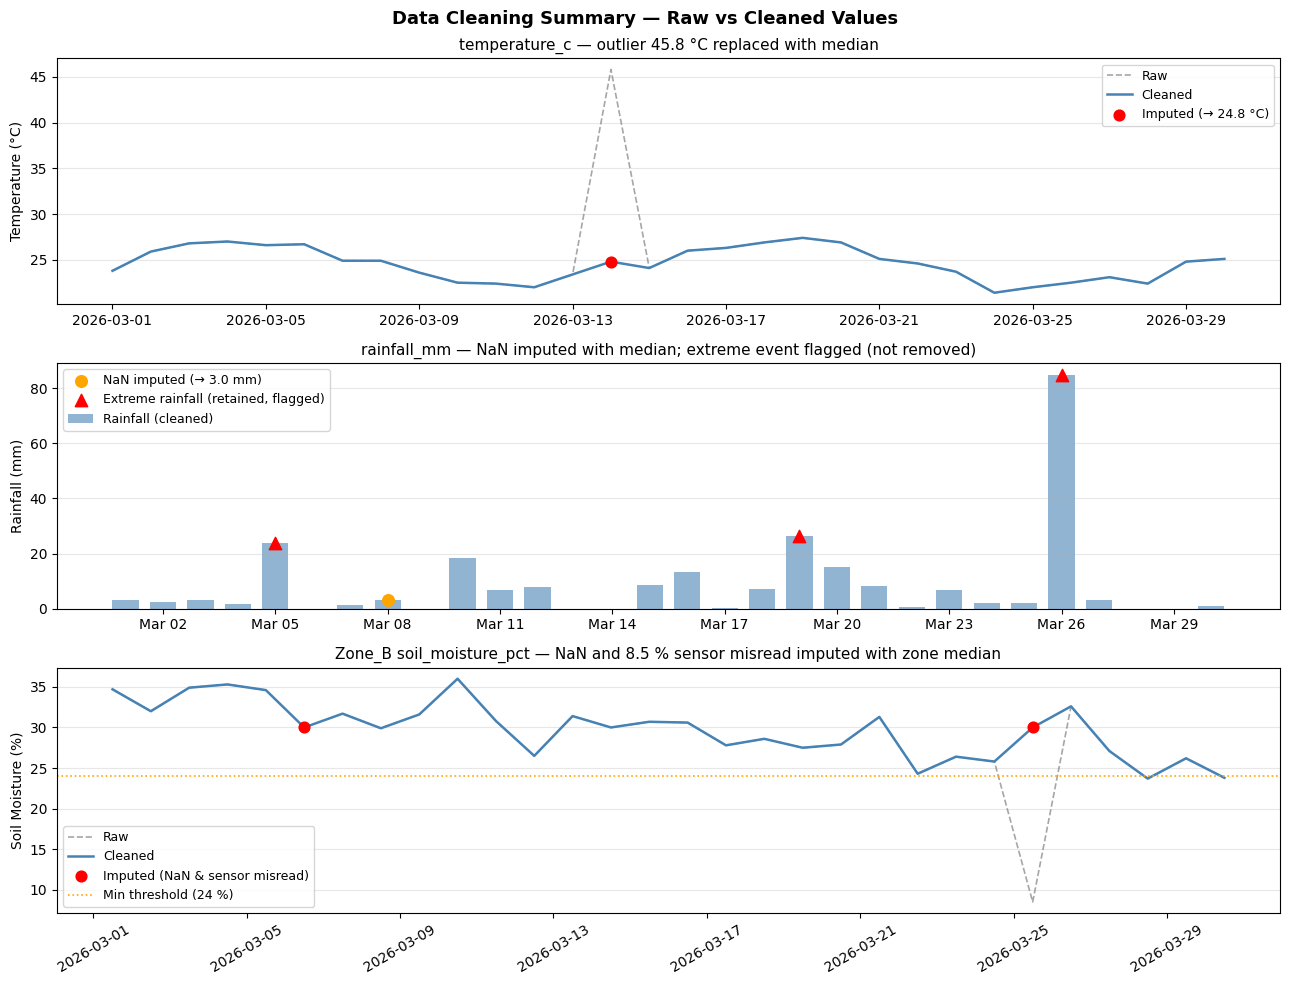

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False)

# ── Panel 1: Temperature ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(pd.to_datetime(weather_raw['date']), weather_raw['temperature_c'],
        color='grey', linewidth=1.2, linestyle='--', alpha=0.7, label='Raw')
ax.plot(weather['date'], weather['temperature_c'],
        color='steelblue', linewidth=1.8, label='Cleaned')
# Mark the imputed point
imp_date = weather.loc[weather['date'] == '2026-03-14', 'date'].values[0]
imp_val  = weather.loc[weather['date'] == '2026-03-14', 'temperature_c'].values[0]
ax.scatter([imp_date], [imp_val], color='red', zorder=5, s=60,
           label=f'Imputed (→ {imp_val:.1f} °C)')
ax.set_ylabel('Temperature (°C)', fontsize=10)
ax.set_title('temperature_c — outlier 45.8 °C replaced with median', fontsize=11)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# ── Panel 2: Rainfall (with flag marker) ────────────────────────────────────
ax = axes[1]
ax.bar(weather['date'], weather['rainfall_mm'],
       color='steelblue', alpha=0.6, width=0.7, label='Rainfall (cleaned)')
# Mark the NaN-imputed day
imp_r_date = pd.Timestamp('2026-03-08')
imp_r_val  = weather.loc[weather['date'] == imp_r_date, 'rainfall_mm'].values[0]
ax.scatter([imp_r_date], [imp_r_val], color='orange', zorder=5, s=70,
           label=f'NaN imputed (→ {imp_r_val:.1f} mm)')
# Mark the flagged extreme
flag_dates = weather.loc[weather['rainfall_flag'], 'date']
flag_vals  = weather.loc[weather['rainfall_flag'], 'rainfall_mm']
ax.scatter(flag_dates, flag_vals, color='red', marker='^', zorder=5, s=80,
           label='Extreme rainfall (retained, flagged)')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_ylabel('Rainfall (mm)', fontsize=10)
ax.set_title('rainfall_mm — NaN imputed with median; extreme event flagged (not removed)', fontsize=11)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# ── Panel 3: Zone_B soil moisture ───────────────────────────────────────────
ax = axes[2]
raw_b  = soil_raw[soil_raw['zone_id'] == 'Zone_B'].copy()
clean_b = soil[soil['zone_id'] == 'Zone_B'].copy()
ax.plot(pd.to_datetime(raw_b['timestamp']),  raw_b['soil_moisture_pct'],
        color='grey', linewidth=1.2, linestyle='--', alpha=0.7, label='Raw')
ax.plot(clean_b['timestamp'], clean_b['soil_moisture_pct'],
        color='steelblue', linewidth=1.8, label='Cleaned')
# Mark imputed points (NaN and 8.5)
imp_dates = pd.to_datetime(['2026-03-06 12:00', '2026-03-25 12:00'])
imp_vals  = clean_b.loc[clean_b['timestamp'].isin(imp_dates), 'soil_moisture_pct'].values
ax.scatter(imp_dates, imp_vals, color='red', zorder=5, s=60,
           label='Imputed (NaN & sensor misread)')
ax.axhline(24, color='orange', linestyle=':', linewidth=1.2, label='Min threshold (24 %)')
ax.set_ylabel('Soil Moisture (%)', fontsize=10)
ax.set_title('Zone_B soil_moisture_pct — NaN and 8.5 % sensor misread imputed with zone median',
             fontsize=11)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=30)
plt.suptitle('Data Cleaning Summary — Raw vs Cleaned Values', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('../outputs/cleaning_summary_level4.png', dpi=150)
plt.show()


## 9. Final Cleaning Decision Log

| ID | Dataset | Column | Rows affected | Issue | Action | Value used | Rationale |
|---|---|---|---|---|---|---|---|
| W1 | weather | `rainfall_mm` | 1 (2026-03-08) | NaN | Replace | Median = 3.0 mm | Rainfall is right-skewed; median is more robust than mean |
| W2 | weather | `humidity_pct` | 1 (2026-03-21) | NaN | Replace | Mean ≈ 65.7 % | Humidity is roughly symmetric; mean is appropriate |
| W3 | weather | `temperature_c` | 1 (2026-03-14) | Outlier 45.8 °C (physically implausible) | Replace | Median (excl. outlier) ≈ 24.9 °C | Median computed after excluding the faulty value to avoid self-bias |
| W4 | weather | `rainfall_mm` | 1 (2026-03-26) | Outlier 85.0 mm | Flag only (`rainfall_flag=True`) | Retained | Extreme rainfall is meteorologically possible; removing it would lose a real signal |
| S1 | soil | `soil_moisture_pct` | 1 (Zone_B 2026-03-06) | NaN | Replace | Zone_B median ≈ 30.7 % | Per-zone median respects zone-specific soil characteristics |
| S2 | soil | `soil_moisture_pct` | 1 (Zone_B 2026-03-25) | 8.5 % — far below Zone_B min threshold (24 %) | Replace | Zone_B median (excl. 8.5) ≈ 30.7 % | Consistent with a sensor misread; no corroborating weather event explains a drop this large |
| S3 | soil | `tank_level_liters` | 1 (Zone_C 2026-03-14) | 9900 L — likely digit error | Replace | Zone_C median (excl. 9900) ≈ 4054 L | Value is nearly double the dataset maximum; plausible transcription error |
| S4 | soil | `pump_flow_lpm` | 1 (Zone_B 2026-03-21) | 0.0 L/min with `sensor_status=CHECK` | Replace + flag | Zone_B median (excl. 0) ≈ 21.6 L/min | Zero flow with normal power draw is physically inconsistent; `sensor_status` updated to `IMPUTED` |
